# Train Faster R-CNN ResNet-50-FPN trên Kaggle

Notebook one-click: bật **GPU** và **Internet**, Add Input là dataset `data/processed/VisDrone`, rồi chọn **Run All**. Notebook tự clone repository `Nhattk19/Object_dectection`, kiểm tra dữ liệu, preview augmentation, smoke test và train full.

- `F0`: baseline pretrained COCO, không augmentation.
- `F1`: giữ nguyên cấu hình F0, chỉ thêm augmentation bbox-safe.
- Smoke test chạy 2 batch để kiểm tra pipeline; kết quả không dùng để báo cáo.


## 1. Cấu hình

Mặc định chỉ cần Add processed dataset. Khi resume từ Kaggle Output cũ, đặt `RESUME_FROM` tới `last.pth` đã Add Input.


In [1]:
!git -C /kaggle/working/Object_dectection \
  pull origin cnn-faster-rcnn-pipeline

fatal: cannot change to '/kaggle/working/Object_dectection': No such file or directory


In [2]:
from pathlib import Path

EXPERIMENT = "F0"

RUN_SMOKE_FIRST = False
TRAIN_FULL = True

EPOCHS = 25
BATCH_SIZE = 2
WORKERS = 2
SEED = 42

RESUME_FROM = (
    "/kaggle/input/datasets/aimy144/faster-rcnn-runsf0/last.pth"
)

REPO_URL = "https://github.com/Nhattk19/Object_dectection.git"
REPO_BRANCH = "cnn-faster-rcnn-pipeline"
PROJECT_ROOT_OVERRIDE = None  # thường không cần sửa
PROCESSED_DATA_ROOT = None    # tự tìm trong /kaggle/input; có thể điền thủ công
RESUME_FROM = None            # ví dụ: /kaggle/input/f0-checkpoint/f0/last.pth
OUTPUT_ROOT = Path("/kaggle/working/faster_rcnn_runs")

assert EXPERIMENT in {"F0", "F1"}


## 2. Clone repository và kiểm tra GPU


In [3]:
import importlib.util
import subprocess
import sys

def find_project_root():
    if PROJECT_ROOT_OVERRIDE:
        candidate = Path(PROJECT_ROOT_OVERRIDE)
        if (candidate / "src" / "faster_rcnn.py").is_file():
            return candidate.resolve()
        raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE không hợp lệ: {candidate}")
    direct = [Path.cwd(), *Path.cwd().parents, Path("/kaggle/working")]
    for candidate in direct:
        if (candidate / "src" / "faster_rcnn.py").is_file():
            return candidate.resolve()
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = list(base.glob("**/src/faster_rcnn.py"))
            if matches:
                return matches[0].parents[1].resolve()
    clone_dir = Path("/kaggle/working/Object_dectection")
    subprocess.check_call(["git", "clone", "--depth", "1", "--branch",
                           REPO_BRANCH, REPO_URL, str(clone_dir)])
    return clone_dir.resolve()

PROJECT_ROOT = find_project_root()
if importlib.util.find_spec("pycocotools") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pycocotools>=2.0.7"])

import torch, torchvision
assert torch.cuda.is_available(), "Chưa có CUDA. Vào Kaggle Settings và bật GPU Accelerator."
print({"project": str(PROJECT_ROOT), "torch": torch.__version__,
       "torchvision": torchvision.__version__, "gpu": torch.cuda.get_device_name(0)})


Cloning into '/kaggle/working/Object_dectection'...


{'project': '/kaggle/working/Object_dectection', 'torch': '2.10.0+cu128', 'torchvision': '0.25.0+cu128', 'gpu': 'Tesla T4'}


## 3. Tìm và kiểm tra processed COCO dataset

Dataset đã Add Input phải chứa `images/train`, `images/val`, `annotations/instances_train.json` và `instances_val.json`. Upload processed data giúp không phải chuyển đổi lại trong mỗi Kaggle session.


In [4]:
def valid_processed_root(path):
    path = Path(path)
    return all((path / item).exists() for item in (
        "images", "annotations/instances_train.json", "annotations/instances_val.json"
    ))

if PROCESSED_DATA_ROOT:
    DATA_ROOT = Path(PROCESSED_DATA_ROOT)
    if not valid_processed_root(DATA_ROOT):
        raise FileNotFoundError(f"Processed dataset không hợp lệ: {DATA_ROOT}")
else:
    candidates = []
    for base in (Path("/kaggle/input"), PROJECT_ROOT / "data"):
        if base.exists():
            candidates.extend(p.parent.parent for p in base.glob("**/annotations/instances_train.json"))
    DATA_ROOT = next((p for p in candidates if valid_processed_root(p)), None)

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Không tìm thấy processed VisDrone trong Kaggle Input. Hãy upload/add thư mục "
        "data/processed/VisDrone hoặc đặt PROCESSED_DATA_ROOT thủ công."
    )

assert valid_processed_root(DATA_ROOT)
import json
train_payload = json.loads((DATA_ROOT / "annotations/instances_train.json").read_text())
val_payload = json.loads((DATA_ROOT / "annotations/instances_val.json").read_text())
print({"processed_root": str(DATA_ROOT), "train_images": len(train_payload["images"]),
       "train_boxes": len(train_payload["annotations"]),
       "val_images": len(val_payload["images"]),
       "val_boxes": len(val_payload["annotations"])})


{'processed_root': '/kaggle/input/datasets/aimy144/visdrone/VisDrone', 'train_images': 6471, 'train_boxes': 343204, 'val_images': 548, 'val_boxes': 38759}


## 4. Preview ground truth và augmentation

Ảnh bên trái là dữ liệu gốc; bên phải là augmentation bbox-safe của F1. F0 không dùng augmentation khi train.


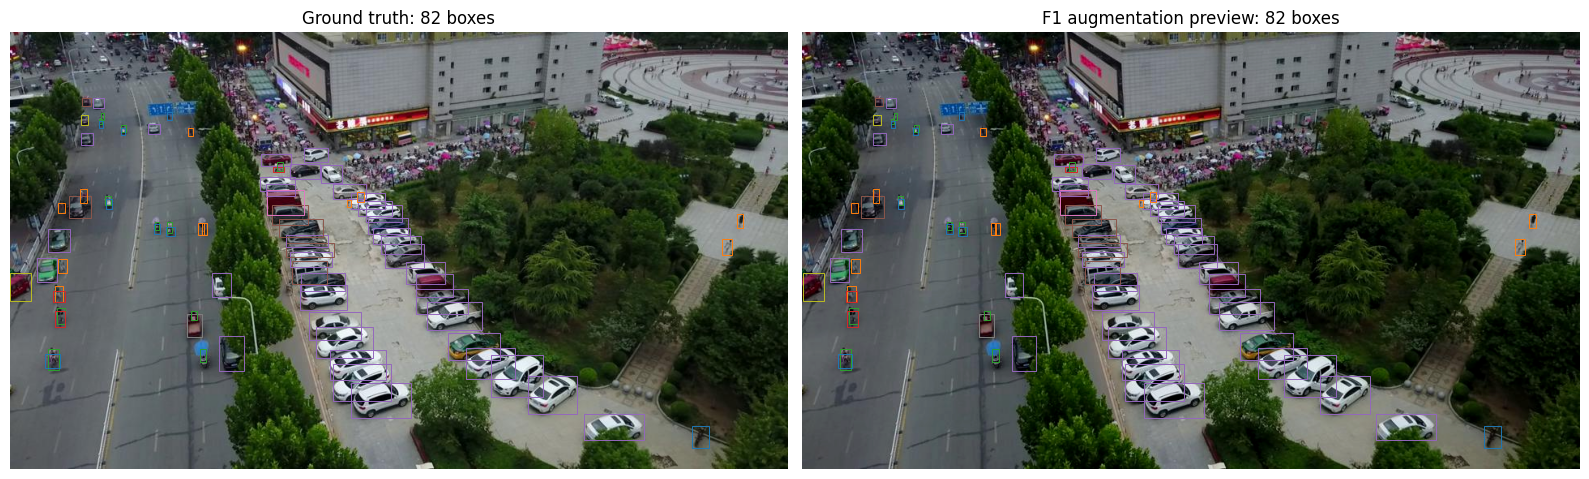

In [5]:
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from augmentation import ControlledDetectionAugmenter
from faster_rcnn import VISDRONE_CLASS_NAMES, VisDroneCocoDataset

TRAIN_JSON = DATA_ROOT / "annotations/instances_train.json"
IMAGE_ROOT = DATA_ROOT / "images"
plain_dataset = VisDroneCocoDataset(TRAIN_JSON, IMAGE_ROOT)
aug_dataset = VisDroneCocoDataset(
    TRAIN_JSON, IMAGE_ROOT, augmentation=ControlledDetectionAugmenter(seed=SEED)
)

def draw_sample(ax, image, target, title, max_boxes=150):
    ax.imshow(image.permute(1, 2, 0).numpy())
    for box, label in zip(target["boxes"][:max_boxes], target["labels"][:max_boxes]):
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                               edgecolor=plt.cm.tab10(int(label) % 10), linewidth=.7))
    ax.set_title(f"{title}: {len(target['boxes'])} boxes")
    ax.axis("off")

plain_image, plain_target = plain_dataset[0]
aug_image, aug_target = aug_dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
draw_sample(axes[0], plain_image, plain_target, "Ground truth")
draw_sample(axes[1], aug_image, aug_target, "F1 augmentation preview")
plt.tight_layout(); plt.show()


## 5. Smoke test rồi train full

Notebook tự chạy smoke test trong thư mục riêng, sau đó khởi tạo lại model pretrained COCO để train full. Output gồm `last.pth`, `best.pth`, `history.csv`, `learning_curves.png`, `config.json` và `summary.json`.


In [6]:
def run_training(output_root, *, smoke=False, resume_from=None):
    command = [
        sys.executable, str(PROJECT_ROOT / "scripts/train_faster_rcnn.py"),
        "--data-root", str(DATA_ROOT), "--output-dir", str(output_root),
        "--experiment", EXPERIMENT, "--epochs", str(EPOCHS),
        "--batch-size", str(BATCH_SIZE), "--workers", str(WORKERS),
        "--seed", str(SEED),
    ]
    if smoke:
        command.append("--smoke-test")
    if resume_from:
        command.extend(["--resume", str(resume_from)])
    print("Running:", " ".join(command))
    subprocess.check_call(command, cwd=PROJECT_ROOT)

if RUN_SMOKE_FIRST and not RESUME_FROM:
    run_training(Path("/kaggle/working/smoke_runs"), smoke=True)
if TRAIN_FULL:
    run_training(OUTPUT_ROOT, resume_from=RESUME_FROM)


Running: /usr/bin/python3 /kaggle/working/Object_dectection/scripts/train_faster_rcnn.py --data-root /kaggle/input/datasets/aimy144/visdrone/VisDrone --output-dir /kaggle/working/faster_rcnn_runs --experiment F0 --epochs 25 --batch-size 2 --workers 2 --seed 42
{
  "config": {
    "experiment": "F0",
    "data_root": "/kaggle/input/datasets/aimy144/visdrone/VisDrone",
    "output_dir": "/kaggle/working/faster_rcnn_runs/f0",
    "epochs": 25,
    "batch_size": 2,
    "workers": 2,
    "seed": 42,
    "min_size": 800,
    "max_size": 1333,
    "pretrained": true,
    "initialize_from_pretrained_this_run": true,
    "augmentation": false,
    "device": "cuda",
    "smoke_test": false
  },
  "dataset": {
    "train": {
      "images": 6471,
      "sample_shape": [
        3,
        540,
        960
      ],
      "sample_boxes": 82,
      "sample_label_min": 1,
      "sample_label_max": 10
    },
    "val": {
      "images": 548,
      "sample_shape": [
        3,
        1080,
        192

100%|██████████| 160M/160M [00:00<00:00, 221MB/s]


Epoch 1/25


{"epoch": 1, "lr": 0.0025, "loss_classifier": 0.43481956737297867, "loss_box_reg": 0.41971890453355126, "loss_objectness": 0.11802148688509738, "loss_rpn_box_reg": 0.22778856526537625, "loss_total": 1.2003485246461314, "seconds": 1163.30915229, "map": 0.13816002287969747, "map_50": 0.24910656250814628, "map_75": 0.13431964243026975, "map_small": 0.07486493619796526, "map_medium": 0.20051049113379388, "map_large": 0.3338971671182698, "mar_1": 0.06336868270163215, "mar_10": 0.17297467559626084, "mar_100": 0.2166313428643795, "mar_small": 0.13574366915291855, "mar_medium": 0.30870845006055014, "mar_large": 0.447003571637068}
Epoch 2/25


{"epoch": 2, "lr": 0.0025, "loss_classifier": 0.3577125531970092, "loss_box_reg": 0.38417654171843907, "loss_objectness": 0.08435503708337387, "loss_rpn_box_reg": 0.20202941404829983, "loss_total": 1.0282735456983076, "seconds": 1086.011457149, "map": 0.16272651637969454, "map_50": 0.29185951986113207, "map_75": 0.16235932707562495, "map_small": 0.09029894021711282, "map_medium": 0.24577441605955097, "map_large": 0.3457280852522228, "mar_1": 0.07797646903029377, "mar_10": 0.20315364498324734, "mar_100": 0.25039452164930187, "mar_small": 0.16064612161638653, "mar_medium": 0.36700062415355894, "mar_large": 0.47052939700720886}
Epoch 3/25


...

{"epoch": 21, "lr": 2.5e-05, "loss_classifier": 0.1580521296850798, "loss_box_reg": 0.2673677226099127, "loss_objectness": 0.028889880210683352, "loss_rpn_box_reg": 0.11564244806870622, "loss_total": 0.5699521805918389, "seconds": 1089.8748528059987, "map": 0.2217458777963944, "map_50": 0.38366323870975916, "map_75": 0.22181223855778057, "map_small": 0.13952602919670823, "map_medium": 0.31873419347709947, "map_large": 0.40103715430023545, "mar_1": 0.10090350686346505, "mar_10": 0.26209210434274194, "mar_100": 0.3149490597061779, "mar_small": 0.22810695043436816, "mar_medium": 0.4307964990260257, "mar_large": 0.48914017556254885}
Epoch 22/25


{"epoch": 22, "lr": 2.5e-05, "loss_classifier": 0.15770029807889233, "loss_box_reg": 0.2666218307810952, "loss_objectness": 0.029018852882770774, "loss_rpn_box_reg": 0.1153454204973919, "loss_total": 0.5686864027631445, "seconds": 1087.9545271589996, "map": 0.22150332623510272, "map_50": 0.38387084910213154, "map_75": 0.22093806674936792, "map_small": 0.13919690750414337, "map_medium": 0.31839045342530586, "map_large": 0.4000944733794014, "mar_1": 0.1001386289125235, "mar_10": 0.2613498222393343, "mar_100": 0.31413313880174704, "mar_small": 0.22756077849719805, "mar_medium": 0.4289003242354269, "mar_large": 0.4878674354884267}
Epoch 23/25


{"epoch": 23, "lr": 2.5e-05, "loss_classifier": 0.15710146996458563, "loss_box_reg": 0.2664720821533955, "loss_objectness": 0.029081589497792177, "loss_rpn_box_reg": 0.11529168501197434, "loss_total": 0.5679468261239169, "seconds": 1087.1183117500004, "map": 0.220873109401372, "map_50": 0.38316501251780594, "map_75": 0.22131288068932928, "map_small": 0.13899383927776085, "map_medium": 0.3178922455134299, "map_large": 0.40532423012468616, "mar_1": 0.100287919841735, "mar_10": 0.2616561331932846, "mar_100": 0.3144182808637554, "mar_small": 0.22749563247577523, "mar_medium": 0.43085010079888475, "mar_large": 0.492152211167477}
Epoch 24/25


{"epoch": 24, "lr": 2.5e-05, "loss_classifier": 0.15678757565195023, "loss_box_reg": 0.2657145766750881, "loss_objectness": 0.028543440355834112, "loss_rpn_box_reg": 0.11520751039185291, "loss_total": 0.5662531038822217, "seconds": 1090.421568226, "map": 0.22053748889008165, "map_50": 0.38204732049950385, "map_75": 0.22089281880777445, "map_small": 0.1393820026795562, "map_medium": 0.31649361032106343, "map_large": 0.3969791304318082, "mar_1": 0.0998161943029491, "mar_10": 0.26088871062268315, "mar_100": 0.31378685330537537, "mar_small": 0.22840440586132743, "mar_medium": 0.4275434737246999, "mar_large": 0.4889858189830448}
Epoch 25/25


{"epoch": 25, "lr": 2.5e-05, "loss_classifier": 0.15678967945266178, "loss_box_reg": 0.26570066961152444, "loss_objectness": 0.028357960381392593, "loss_rpn_box_reg": 0.11512815192716233, "loss_total": 0.5659764613253979, "seconds": 1089.3912465169997, "map": 0.2202330502152942, "map_50": 0.38277313969731735, "map_75": 0.2194935003987075, "map_small": 0.13846036597599248, "map_medium": 0.3172433741689187, "map_large": 0.4012393148542173, "mar_1": 0.09980207723450779, "mar_10": 0.2613916400006961, "mar_100": 0.314046930835994, "mar_small": 0.22699836281234245, "mar_medium": 0.4300606900668167, "mar_large": 0.49182615436276}
{
  "experiment": "F0",
  "completed_epochs": 25,
  "best_map": 0.2241590765865697,
  "peak_vram_gb": 10.498313426971436,
  "last_metrics": {
    "epoch": 25,
    "lr": 2.5e-05,
    "loss_classifier": 0.15678967945266178,
    "loss_box_reg": 0.26570066961152444,
    "loss_objectness": 0.028357960381392593,
    "loss_rpn_box_reg": 0.11512815192716233,
    "loss_total"

## 6. Xem kết quả và tạo Kaggle Output


,experiment,completed_epochs,best_map,peak_vram_gb,last_metrics,run_dir
0,F0,25,0.224159,10.498313,"{'epoch': 25, 'lr': 2.5e-05, 'loss_classifier'...",/kaggle/working/faster_rcnn_runs/f0


,epoch,lr,loss_classifier,loss_box_reg,loss_objectness,loss_rpn_box_reg,loss_total,seconds,map,map_50,map_75,map_small,map_medium,map_large,mar_1,mar_10,mar_100,mar_small,mar_medium,mar_large
0,1,0.002500,0.434820,0.419719,0.118021,0.227789,1.200349,1163.309152,0.138160,0.249107,0.134320,0.074865,0.200510,0.333897,0.063369,0.172975,0.216631,0.135744,0.308708,0.447004
1,2,0.002500,0.357713,0.384177,0.084355,0.202029,1.028274,1086.011457,0.162727,0.291860,0.162359,0.090299,0.245774,0.345728,0.077976,0.203154,0.250395,0.160646,0.367001,0.470529
2,3,0.002500,0.327466,0.369531,0.073980,0.189791,0.960767,1106.748633,0.178513,0.312179,0.179121,0.105775,0.261461,0.361410,0.083105,0.209375,0.259100,0.172977,0.374500,0.521254
3,4,0.002500,0.308925,0.359075,0.066859,0.183012,0.917872,1086.998463,0.185911,0.328858,0.184179,0.107365,0.276464,0.382605,0.090591,0.239716,0.288754,0.203897,0.401021,0.517034
4,5,0.002500,0.294028,0.352355,0.063710,0.176829,0.886922,1089.946737,0.196162,0.345640,0.193452,0.116309,0.292474,0.421573,0.093546,0.242123,0.293230,0.198366,0.414176,0.512652
5,6,0.002500,0.282181,0.346720,0.058763,0.171077,0.858741,1087.108906,0.199321,0.348773,0.199150,0.120263,0.290521,0.406365,0.089404,0.236596,0.290676,0.201721,0.404717,0.511326
6,7,0.002500,0.271422,0.341118,0.056190,0.166992,0.835721,1086.815903,0.189844,0.335762,0.192279,0.113767,0.277879,0.387486,0.087980,0.234051,0.284436,0.194840,0.395740,0.540640
7,8,0.002500,0.262495,0.335936,0.054186,0.163000,0.815617,1088.857348,0.193153,0.342922,0.192561,0.119716,0.282938,0.411023,0.088326,0.234192,0.283735,0.196483,0.399942,0.556487
8,9,0.002500,0.253624,0.332223,0.051115,0.159759,0.796721,1088.167476,0.196153,0.343059,0.196172,0.122016,0.285888,0.381702,0.091358,0.239976,0.290735,0.202217,0.407752,0.500945
9,10,0.002500,0.249109,0.329470,0.050242,0.157307,0.786127,1087.722736,0.202875,0.353634,0.206577,0.124063,0.297806,0.420989,0.094767,0.243995,0.293376,0.203249,0.414544,0.507354


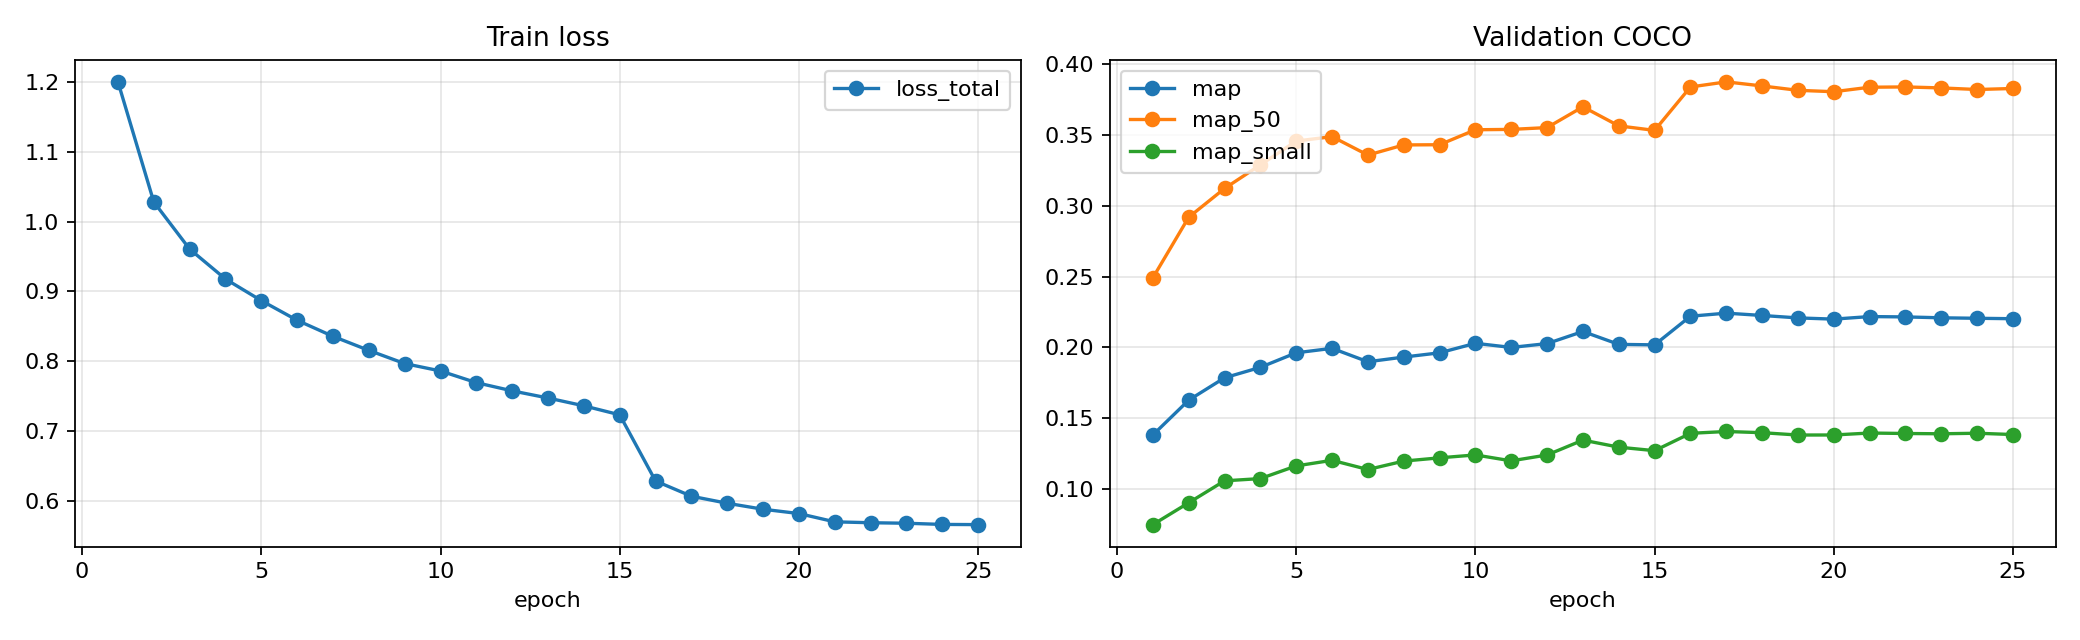

Artifacts để Save Version / tải về: /kaggle/working/faster_rcnn_runs/f0


In [7]:
import json
import pandas as pd
from IPython.display import Image as DisplayImage, display

RUN_DIR = OUTPUT_ROOT / EXPERIMENT.lower()
summary = json.loads((RUN_DIR / "summary.json").read_text())
display(pd.DataFrame([summary]))
display(pd.read_csv(RUN_DIR / "history.csv"))
if (RUN_DIR / "learning_curves.png").is_file():
    display(DisplayImage(filename=str(RUN_DIR / "learning_curves.png")))
print("Artifacts để Save Version / tải về:", RUN_DIR)
